# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram
from matplotlib import cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.cm as cm
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
df = pd.read_csv("ranking_AI_2025.csv", encoding="latin-1")

In [ ]:
df

,Overall,Country,Talent,Infrastructure,Operating environment,Research,Development,Government strategy,Commercial ecosystem,Scale,Intensity
0,100,US,100,100,47,100,100,94,100,100,75
1,74,China,54,91,64,80,79,84,45,78,37
2,49,European Union,29,51,53,46,48,94,29,49,37
3,40,Singapore,39,37,100,31,17,68,22,24,100
4,36,UK,26,19,52,26,29,91,26,30,52
...,...,...,...,...,...,...,...,...,...,...,...
89,7,Zambia,2,3,35,0,0,27,0,6,8
90,6,Iraq,4,9,31,1,0,14,0,6,8
91,6,Ethiopia,3,0,32,0,0,26,0,6,7
92,6,Cambodia,2,6,33,0,0,13,2,6,8


In [ ]:
features = ['Talent', 'Infrastructure', 'Operating environment',
            'Research', 'Development', 'Government strategy',
            'Commercial ecosystem', 'Scale', 'Intensity']

In [ ]:
X = df[features]

In [ ]:
df['Economic'] = (
    df['Commercial ecosystem'] * 0.30 +
    df['Talent']               * 0.25 +
    df['Scale']                * 0.20 +
    df['Development']          * 0.15 +
    df['Infrastructure']       * 0.10
).round(2)

print(df[['Country', 'Economic']].sort_values('Economic', ascending=False).to_string(index=False))

       Country  Economic
            US    100.00
         China     63.55
European Union     38.05
    Singapore      27.40
           UK      26.55
       Israel      25.00
        France     23.35
       Canada      22.75
  South Korea      22.15
      Germany      21.20
        India      18.70
        Japan      17.20
  Switzerland      17.20
  Netherlands      16.50
          UAE      14.70
       Sweden      14.25
  Saudi Arabia     14.20
      Finland      13.20
       Ireland     11.60
       Taiwan      11.45
    Australia      11.25
       Estonia     11.05
         Spain     10.90
       Norway      10.85
       Denmark     10.55
        Brazil     10.45
       Russia       9.95
      Iceland       9.90
    Luxembourg      9.80
       Greece       9.40
      Austria       9.05
      Belgium       8.95
        Poland      8.35
        Italy       8.20
     Malaysia       8.15
       Bahrain      7.75
   New Zealand      7.60
       Vietnam      7.45
       Hungary      7.20


## Economic Factor — Feature Weights

| Feature | Economic Pillar | Weight | Reason |
|---|---|---|---|
| **Commercial ecosystem** | Investment + Corporate Activity | 30% | Directly maps to startup activity, corporate investment, industry usage — the core of economic integration |
| **Talent** | Jobs + AI Labor | 25% | AI labor demand, hiring rates, skill penetration — workforce is the engine of economic output |
| **Scale** | Corporate Activity + Robots | 20% | Reflects deployment size, industry adoption, robot deployments — measures actual economic footprint |
| **Development** | Corporate Investment | 15% | R&D spending, product development — translates research into economic value |
| **Infrastructure** | Robot Deployments | 10% | Enables deployment of AI/robots in industry — foundational but indirect economic driver |

### Formula
$$Economic = (Commercial\ ecosystem \times 0.30) + (Talent \times 0.25) + (Scale \times 0.20) + (Development \times 0.15) + (Infrastructure \times 0.10)$$

In [ ]:
# ── REMOVE US AND CHINA ──────────────────────────────────────────
# df = df[~df['Country'].isin(['US', 'China'])].reset_index(drop=True)

#  print(f"✅ US and China removed | {len(df)} countries remaining:")

In [ ]:
features = ['Commercial ecosystem', 'Economic','overall']

In [ ]:
# ── 2. DEFINE FEATURES ───────────────────────────────────────────
features_hc = ['Commercial ecosystem', 'Economic', 'Overall']
X = df[features_hc]

print("✅ Features ready:")
print(df[['Country'] + features_hc].to_string(index=False))

✅ Features ready:
       Country  Commercial ecosystem  Economic  Overall
            US                   100    100.00      100
         China                    45     63.55       74
European Union                    29     38.05       49
    Singapore                     22     27.40       40
           UK                     26     26.55       36
  South Korea                     14     22.15       36
        France                    17     23.35       35
       Israel                     31     25.00       33
       Canada                     23     22.75       31
      Germany                     15     21.20       28
          UAE                     17     14.70       28
        Japan                     16     17.20       25
  Switzerland                     14     17.20       25
  Netherlands                     19     16.50       24
  Saudi Arabia                    24     14.20       24
      Finland                     13     13.20       23
       Taiwan                 

c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

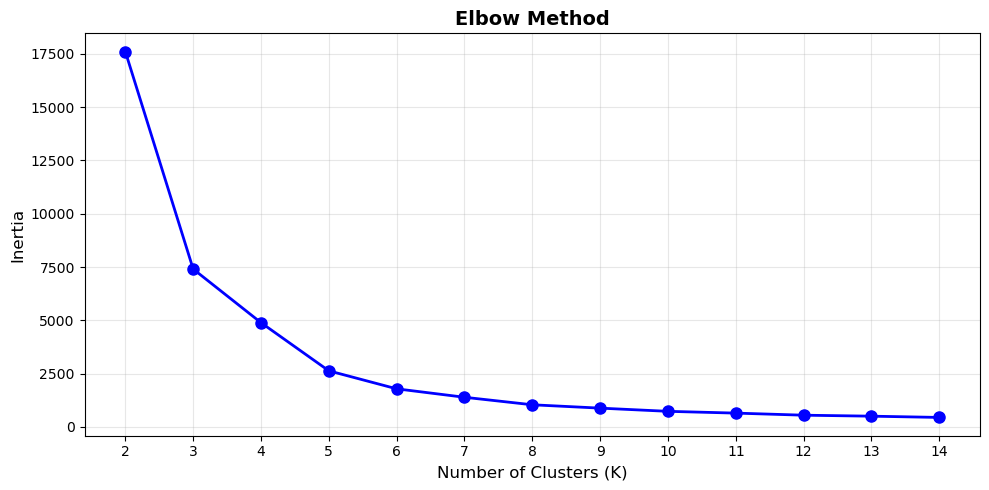

In [ ]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('elbow.png', dpi=150, bbox_inches='tight')
plt.show()


c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

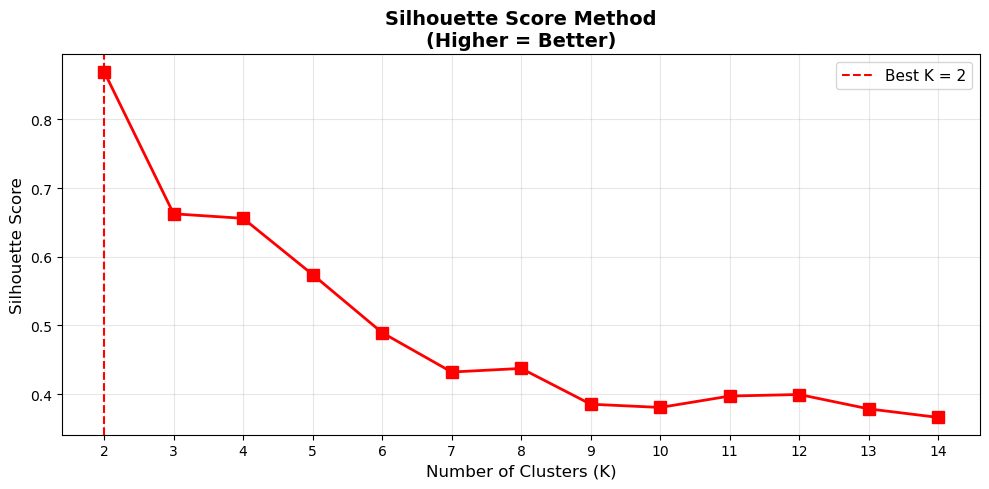

✅ Best K by Silhouette Score: 2


In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []
K_range    = range(2, 15)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

best_k_sil = K_range[np.argmax(sil_scores)]

plt.figure(figsize=(10, 5))
plt.plot(K_range, sil_scores, 'rs-', linewidth=2, markersize=8)
plt.axvline(x=best_k_sil, color='red', linestyle='--',
            label=f'Best K = {best_k_sil}')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score Method\n(Higher = Better)', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Best K by Silhouette Score: {best_k_sil}")

c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

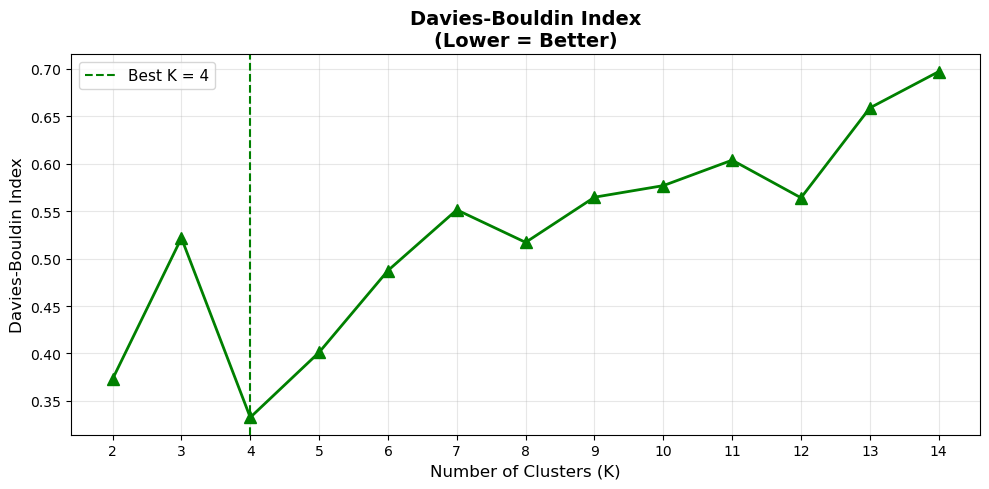

✅ Best K by Davies-Bouldin Index: 4


In [ ]:
from sklearn.metrics import davies_bouldin_score

db_scores = []
K_range   = range(2, 15)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    db_scores.append(davies_bouldin_score(X, labels))

best_k_db = K_range[np.argmin(db_scores)]  # lower is better

plt.figure(figsize=(10, 5))
plt.plot(K_range, db_scores, 'g^-', linewidth=2, markersize=8)
plt.axvline(x=best_k_db, color='green', linestyle='--',
            label=f'Best K = {best_k_db}')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Davies-Bouldin Index', fontsize=12)
plt.title('Davies-Bouldin Index\n(Lower = Better)', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('davies_bouldin.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Best K by Davies-Bouldin Index: {best_k_db}")

c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

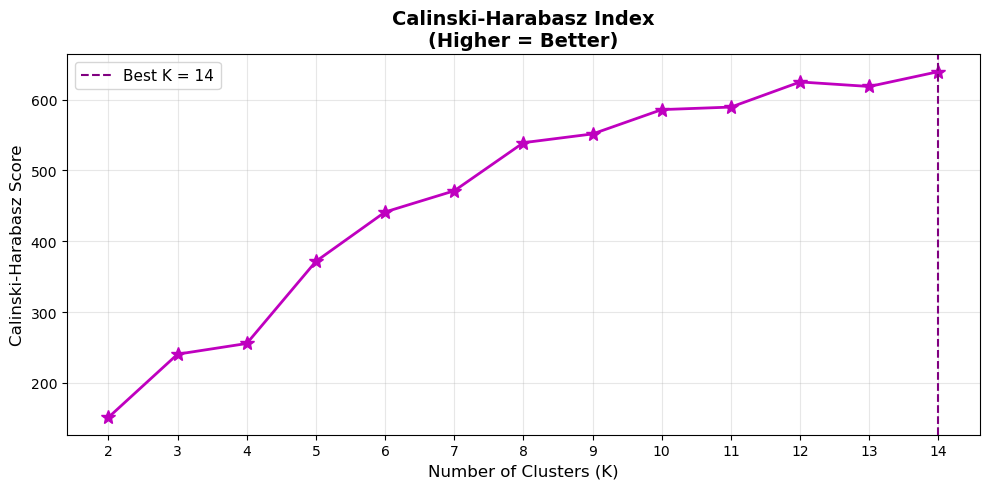

✅ Best K by Calinski-Harabasz Index: 14


In [ ]:
from sklearn.metrics import calinski_harabasz_score

ch_scores = []
K_range   = range(2, 15)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    ch_scores.append(calinski_harabasz_score(X, labels))

best_k_ch = K_range[np.argmax(ch_scores)]  # higher is better

plt.figure(figsize=(10, 5))
plt.plot(K_range, ch_scores, 'm*-', linewidth=2, markersize=10)
plt.axvline(x=best_k_ch, color='purple', linestyle='--',
            label=f'Best K = {best_k_ch}')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Calinski-Harabasz Score', fontsize=12)
plt.title('Calinski-Harabasz Index\n(Higher = Better)', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('calinski_harabasz.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Best K by Calinski-Harabasz Index: {best_k_ch}")

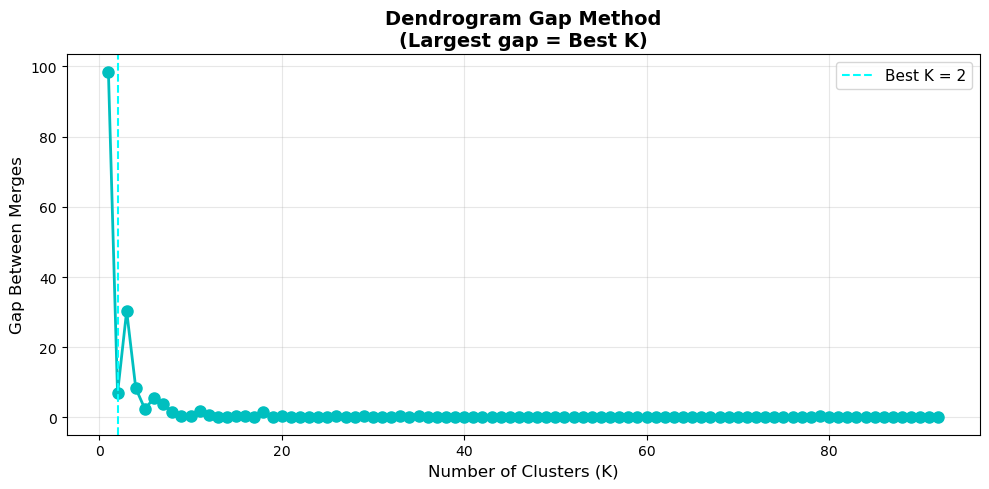

✅ Best K by Dendrogram Gap: 2


In [ ]:
from scipy.cluster.hierarchy import linkage

linked    = linkage(X, method='complete')
distances = linked[:, 2]
gaps      = np.diff(distances)
best_k_dendro = len(distances) - np.argmax(gaps)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(gaps)+1), gaps[::-1], 'co-', linewidth=2, markersize=8)
plt.axvline(x=best_k_dendro, color='cyan', linestyle='--',
            label=f'Best K = {best_k_dendro}')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Gap Between Merges', fontsize=12)
plt.title('Dendrogram Gap Method\n(Largest gap = Best K)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dendrogram_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Best K by Dendrogram Gap: {best_k_dendro}")

In [ ]:
print("=" * 45)
print("   IDEAL K SUMMARY ACROSS ALL METHODS")
print("=" * 45)
print(f"  Elbow Method          → inspect plot visually")
print(f"  Silhouette Score      → K = {best_k_sil}")
print(f"  Davies-Bouldin Index  → K = {best_k_db}")
print(f"  Calinski-Harabasz     → K = {best_k_ch}")
print(f"  Dendrogram Gap        → K = {best_k_dendro}")
print("=" * 45)

# Majority vote
from collections import Counter
votes    = [best_k_sil, best_k_db, best_k_ch, best_k_dendro]
majority = Counter(votes).most_common(1)[0][0]
print(f"\n  ✅ Majority Vote Best K: {majority}")
print("=" * 45)

   IDEAL K SUMMARY ACROSS ALL METHODS
  Elbow Method          → inspect plot visually
  Silhouette Score      → K = 2
  Davies-Bouldin Index  → K = 4
  Calinski-Harabasz     → K = 14
  Dendrogram Gap        → K = 2

  ✅ Majority Vote Best K: 2


In [ ]:
best_k = 10

In [ ]:
linked = linkage(X, method='complete')

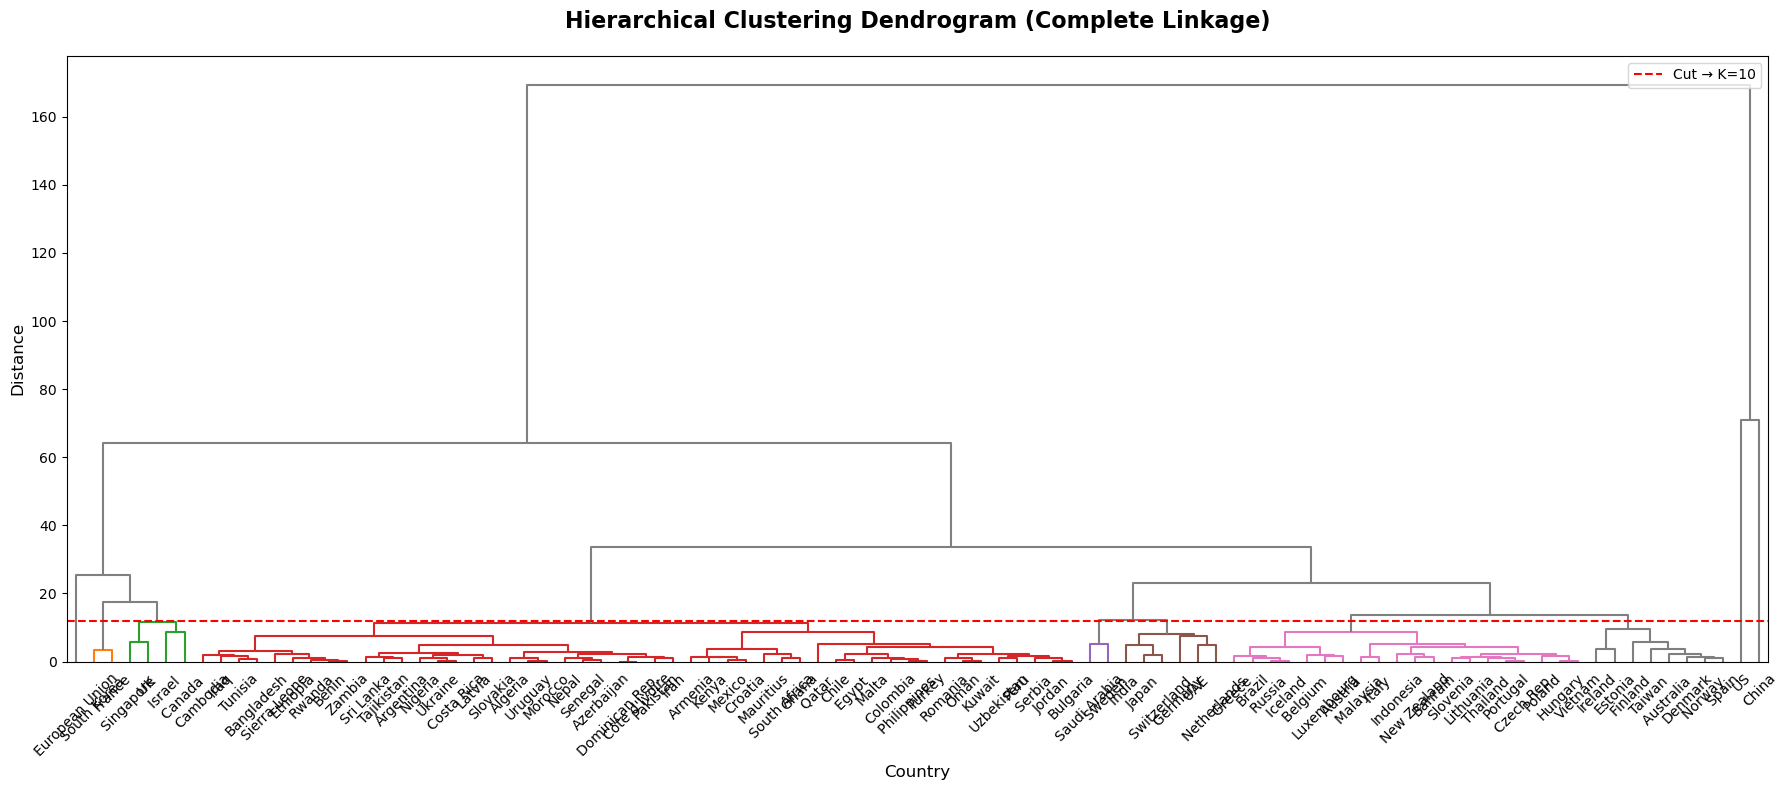

✅ Saved: dendrogram_complete.png


In [ ]:
plt.figure(figsize=(18, 8))
plt.title(f'Hierarchical Clustering Dendrogram (Complete Linkage)',
          fontsize=16, fontweight='bold', pad=20)

dendrogram(
    linked,
    labels=df['Country'].values,
    orientation='top',
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=linked[-(best_k-1), 2],
    above_threshold_color='gray'
)

cut_height = (linked[-(best_k-1), 2] + linked[-(best_k), 2]) / 2
plt.axhline(y=cut_height, color='red', linewidth=1.5,
            linestyle='--', label=f'Cut → K={best_k}')

plt.xlabel('Country', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('dendrogram_complete.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: dendrogram_complete.png")

In [ ]:
df['HC_Cluster'] = fcluster(linked, t=best_k, criterion='maxclust')

print(f"✅ Clusters assigned with K={best_k}")
print(df[['Country', 'HC_Cluster']].sort_values('HC_Cluster').to_string(index=False))

✅ Clusters assigned with K=10
       Country  HC_Cluster
  South Korea            1
        France           1
       Canada            2
    Singapore            2
           UK            2
       Israel            2
European Union           3
      Slovakia           4
       Ukraine           4
       Algeria           4
       Armenia           4
         Chile           4
       Morocco           4
          Peru           4
       Nigeria           4
       Uruguay           4
         Ghana           4
          Oman           4
        Kuwait           4
         Malta           4
     Mauritius           4
    Uzbekistan           4
      Bulgaria           4
  South Africa           4
      Colombia           4
       Serbia            4
        Latvia           4
    Costa Rica           4
       Senegal           4
    Tajikistan           4
      Ethiopia           4
          Iraq           4
        Zambia           4
         Benin           4
    Bangladesh           

In [ ]:
cluster_rank_hc = df.groupby('HC_Cluster').agg(
    Countries   = ('Country',              lambda x: ', '.join(x)),
    Count       = ('Country',              'count'),
    Avg_Overall = ('Overall',              'mean'),
    Avg_CommEco = ('Commercial ecosystem', 'mean'),
    Avg_Econ    = ('Economic',             'mean'),
).round(1).sort_values('Avg_CommEco', ascending=False)

cluster_rank_hc.insert(0, 'Rank', range(1, len(cluster_rank_hc) + 1))

hc_to_rank    = dict(zip(cluster_rank_hc.index, cluster_rank_hc['Avg_CommEco']))
df['HC_Rank'] = df['HC_Cluster'].map(hc_to_rank)

print(cluster_rank_hc)

            Rank                                          Countries  Count  \
HC_Cluster                                                                   
9              1                                                 US      1   
10             2                                              China      1   
3              3                                     European Union      1   
2              4                  Singapore , UK , Israel , Canada       4   
5              5                              Saudi Arabia, Sweden       2   
6              6  Germany , UAE , Japan , Switzerland , Netherla...      6   
1              7                               South Korea , France      2   
8              8  Finland , Taiwan , Denmark, Norway , Australia...      8   
7              9  Malaysia , Brazil, Luxembourg, Italy , Russia ...     20   
4             10  Qatar , Chile, Egypt , Philippines , Turkey, R...     49   

            Avg_Overall  Avg_CommEco  Avg_Econ  
HC_Cluster    

In [ ]:
cluster_rank_hc

,Rank,Countries,Count,Avg_Overall,Avg_CommEco,Avg_Econ
HC_Cluster,,,,,,
9,1,US,1,100.0,100.0,100.0
10,2,China,1,74.0,45.0,63.6
3,3,European Union,1,49.0,29.0,38.0
2,4,"Singapore , UK , Israel , Canada",4,35.0,25.5,25.4
5,5,"Saudi Arabia, Sweden",2,22.0,22.5,14.2
6,6,"Germany , UAE , Japan , Switzerland , Netherla...",6,25.2,16.2,17.6
1,7,"South Korea , France",2,35.5,15.5,22.8
8,8,"Finland , Taiwan , Denmark, Norway , Australia...",8,19.9,11.6,11.4
7,9,"Malaysia , Brazil, Luxembourg, Italy , Russia ...",20,15.6,7.4,8.2


In [ ]:
print("=" * 65)
print(f"  HIERARCHICAL CLUSTERS — RANKED HIGHEST TO LOWEST (K={best_k})")
print("=" * 65)

for _, row in cluster_rank_hc.iterrows():
    print(f"\n  🏆 Rank #{int(row['Rank'])}  |  Avg Overall: {row['Avg_Overall']:.1f}  |  Countries: {int(row['Count'])}")
    print(f"  {'─' * 55}")
    for country in row['Countries'].split(', '):
        overall = df[df['Country'] == country]['Overall'].values[0]
        econ    = df[df['Country'] == country]['Economic'].values[0]
        comm    = df[df['Country'] == country]['Commercial ecosystem'].values[0]
        print(f"     • {country:<30} Overall: {overall:<6} Economic: {econ:<6} CommEco: {comm}")

  HIERARCHICAL CLUSTERS — RANKED HIGHEST TO LOWEST (K=10)

  🏆 Rank #1  |  Avg Overall: 100.0  |  Countries: 1
  ───────────────────────────────────────────────────────
     • US                             Overall: 100    Economic: 100.0  CommEco: 100

  🏆 Rank #2  |  Avg Overall: 74.0  |  Countries: 1
  ───────────────────────────────────────────────────────
     • China                          Overall: 74     Economic: 63.55  CommEco: 45

  🏆 Rank #3  |  Avg Overall: 49.0  |  Countries: 1
  ───────────────────────────────────────────────────────
     • European Union                 Overall: 49     Economic: 38.05  CommEco: 29

  🏆 Rank #4  |  Avg Overall: 35.0  |  Countries: 4
  ───────────────────────────────────────────────────────
     • Singapore                      Overall: 40     Economic: 27.4   CommEco: 22
     • UK                             Overall: 36     Economic: 26.55  CommEco: 26
     • Israel                         Overall: 33     Economic: 25.0   CommEco: 31
  

In [ ]:
# ── Countries above Canada ────────────────────────────────────────
above_canada = ['US', 'China', 'European Union', 'Singapore', 'UK', 'Israel','France']

df_above = df[df['Country'].isin(above_canada)].copy()

print(f"✅ {len(df_above)} countries | Cluster assignments:")
print(df_above[['Country', 'Overall', 'HC_Cluster', 'HC_Rank']].sort_values('Overall', ascending=False).to_string(index=False))

✅ 4 countries | Cluster assignments:
       Country  Overall  HC_Cluster  HC_Rank
            US      100           9    100.0
         China       74          10     45.0
European Union       49           3     29.0
        France       35           1     15.5


In [ ]:
df['Country'] = df['Country'].str.strip()

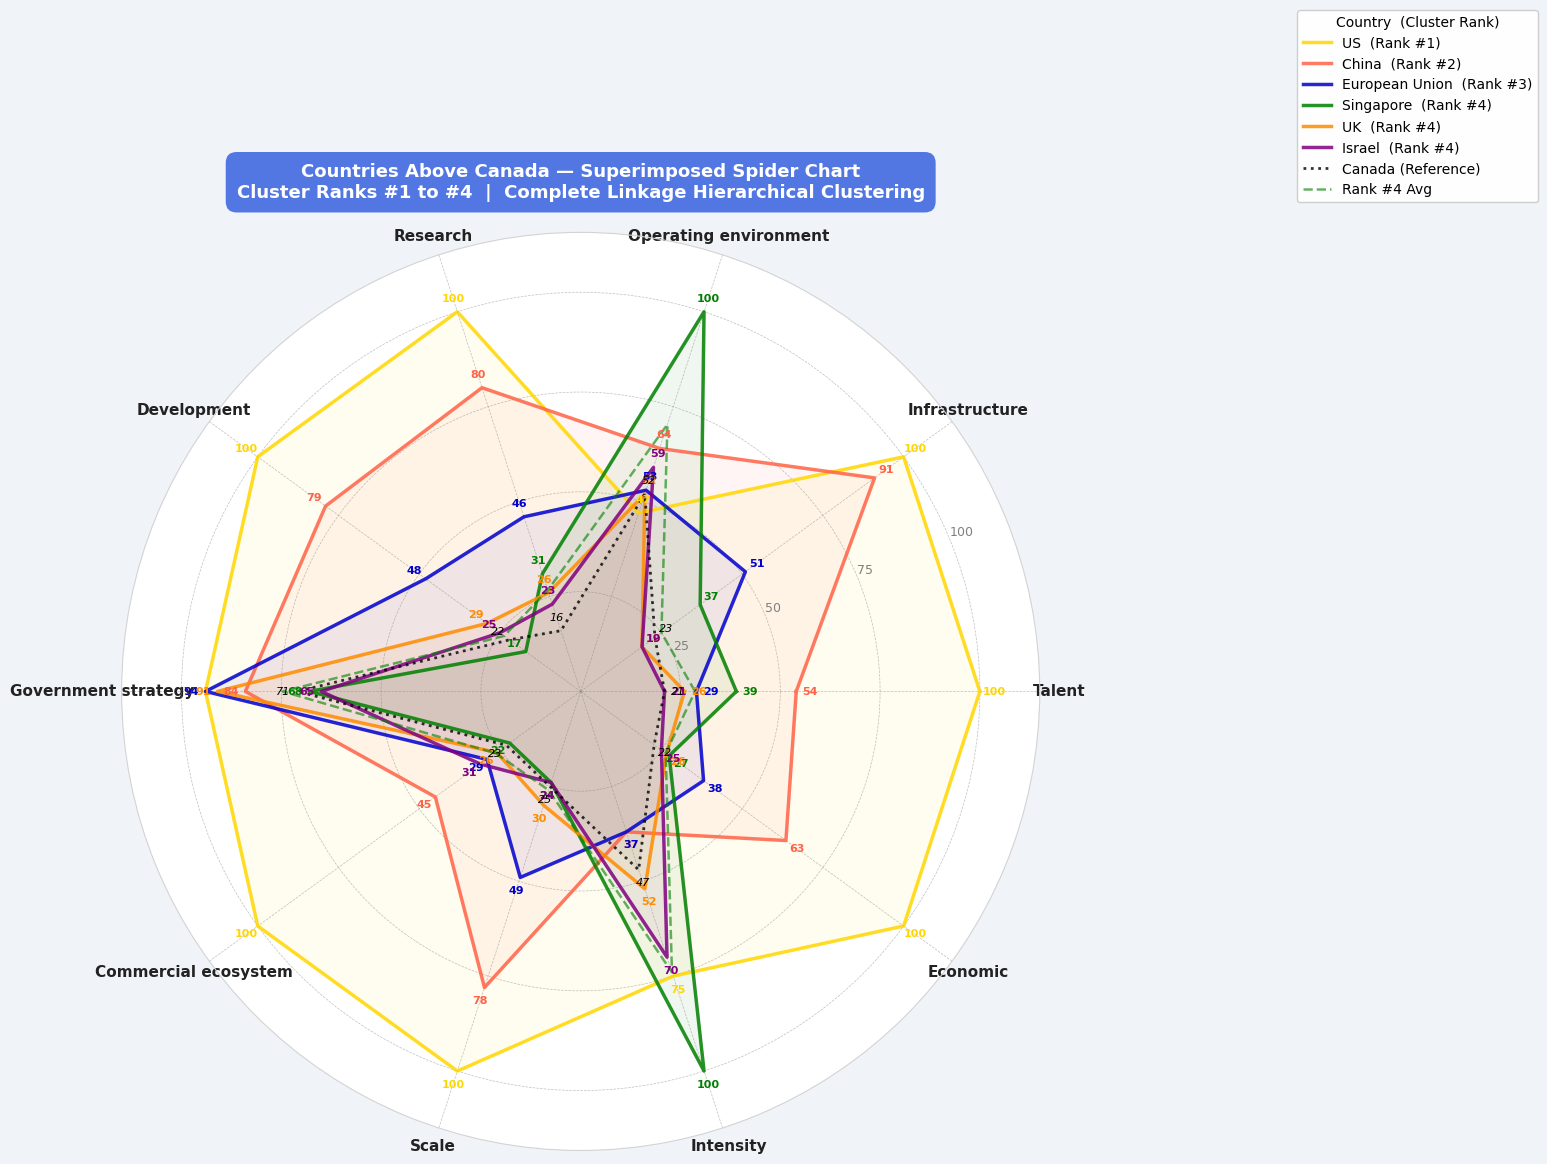

✅ Saved: spider_above_canada.png


In [ ]:
# ── Countries above Canada ────────────────────────────────────────
above_canada = ['US', 'China', 'European Union', 'Singapore', 'UK', 'Israel']

df_above = df[df['Country'].isin(above_canada)].copy()

# ── Fix: color by country directly ───────────────────────────────
country_colors = {
    'US'             : 'gold',
    'China'          : 'tomato',
    'European Union' : 'mediumblue',
    'Singapore'      : 'green',
    'UK'             : 'darkorange',
    'Israel'         : 'purple',
}

# Cluster rank label per country for legend
country_rank_label = {
    'US'             : 'Rank #1',
    'China'          : 'Rank #2',
    'European Union' : 'Rank #3',
    'Singapore'      : 'Rank #4',
    'UK'             : 'Rank #4',
    'Israel'         : 'Rank #4',
}

# ── Spider setup ─────────────────────────────────────────────────
all_features = ['Talent', 'Infrastructure', 'Operating environment',
                'Research', 'Development', 'Government strategy',
                'Commercial ecosystem', 'Scale', 'Intensity',
                'Economic']  # ← added here

N      = len(all_features)  # now 10 instead of 9
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# ── Large figure ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#f0f4f8')
ax.set_facecolor('#ffffff')

# ── Plot each country ─────────────────────────────────────────────
for _, row in df_above.iterrows():
    country = row['Country']
    color   = country_colors[country]
    rank    = country_rank_label[country]
    values  = [row[f] for f in all_features]
    values += values[:1]

    ax.plot(angles, values,
            color=color, linewidth=2.5,
            linestyle='solid', alpha=0.85,
            label=f'{country}  ({rank})')
    ax.fill(angles, values, color=color, alpha=0.06)

    # Score labels on each vertex
    for angle, value in zip(angles[:-1], values[:-1]):
        ax.text(angle, value + 3.5, f'{int(value)}',
                ha='center', va='center',
                fontsize=8, color=color, fontweight='bold')

# ── Canada as reference line ──────────────────────────────────────
canada = df[df['Country'] == 'Canada'].iloc[0]
canada_vals  = [canada[f] for f in all_features]
canada_vals += canada_vals[:1]

ax.plot(angles, canada_vals,
        color='black', linewidth=2,
        linestyle=':', alpha=0.8,
        label='Canada (Reference)')
ax.fill(angles, canada_vals, color='black', alpha=0.03)

# Score labels
for angle, value in zip(angles[:-1], canada_vals[:-1]):
    ax.text(angle, value + 3.5, f'{int(value)}',
            ha='center', va='center',
            fontsize=8, color='black', fontstyle='italic')
# ── Cluster average lines ─────────────────────────────────────────
# Rank 4 average (Singapore, UK, Israel)
rank4_countries = df[df['Country'].isin(['Singapore', 'UK', 'Israel'])]
rank4_avg       = [rank4_countries[f].mean() for f in all_features]
rank4_avg      += rank4_avg[:1]
ax.plot(angles, rank4_avg, color='green', linewidth=1.8,
        linestyle='--', alpha=0.6, label='Rank #4 Avg')

# ── Styling ───────────────────────────────────────────────────────
ax.set_xticks(angles[:-1])
ax.set_xticklabels(all_features, fontsize=11,
                   color='#222222', fontweight='bold')
ax.set_ylim(0, 115)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(['25', '50', '75', '100'], fontsize=9, color='gray')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.spines['polar'].set_color('lightgray')

# ── Legend ────────────────────────────────────────────────────────
ax.legend(loc='upper right',
          bbox_to_anchor=(1.55, 1.25),
          fontsize=10, framealpha=0.95,
          title='Country  (Cluster Rank)',
          title_fontsize=10)

# ── Title ─────────────────────────────────────────────────────────
ax.set_title(
    'Countries Above Canada — Superimposed Spider Chart\n'
    'Cluster Ranks #1 to #4  |  Complete Linkage Hierarchical Clustering',
    size=13, fontweight='bold', color='white', pad=25,
    bbox=dict(boxstyle='round,pad=0.6',
              facecolor='royalblue', edgecolor='none', alpha=0.9)
)

plt.tight_layout()
plt.savefig('spider_above_canada.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved: spider_above_canada.png")

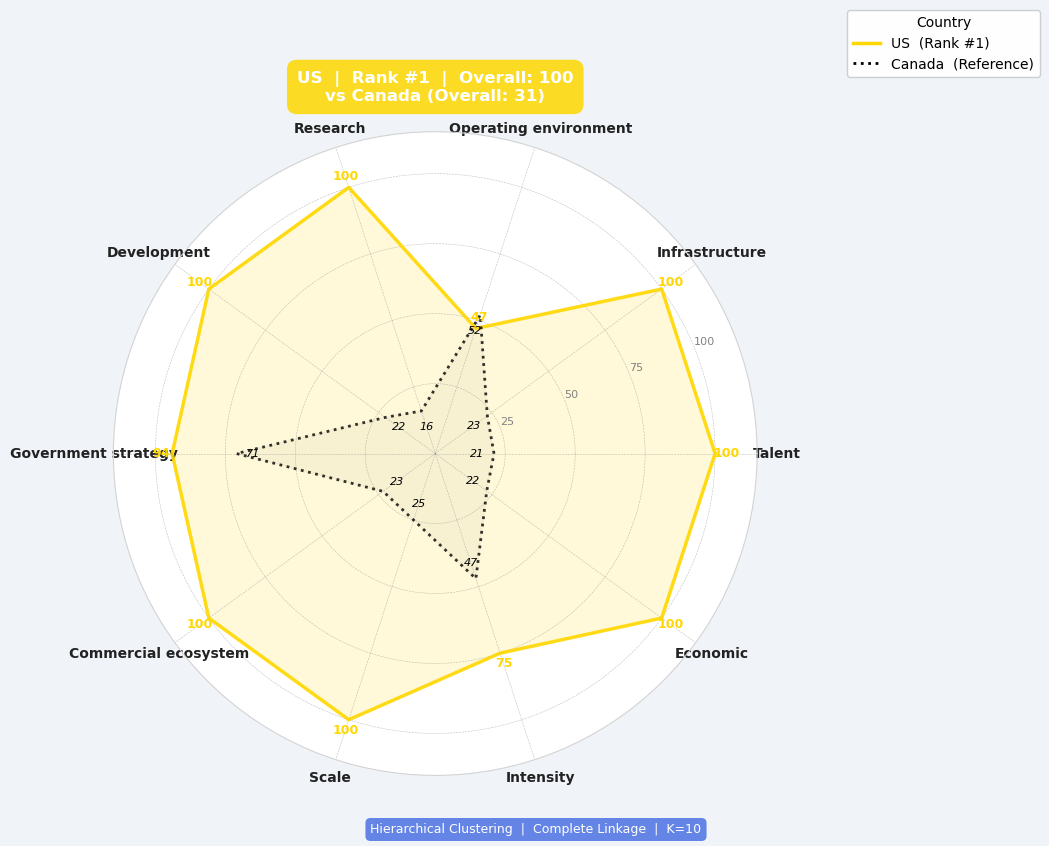

✅ Saved: spider_US_vs_Canada.png


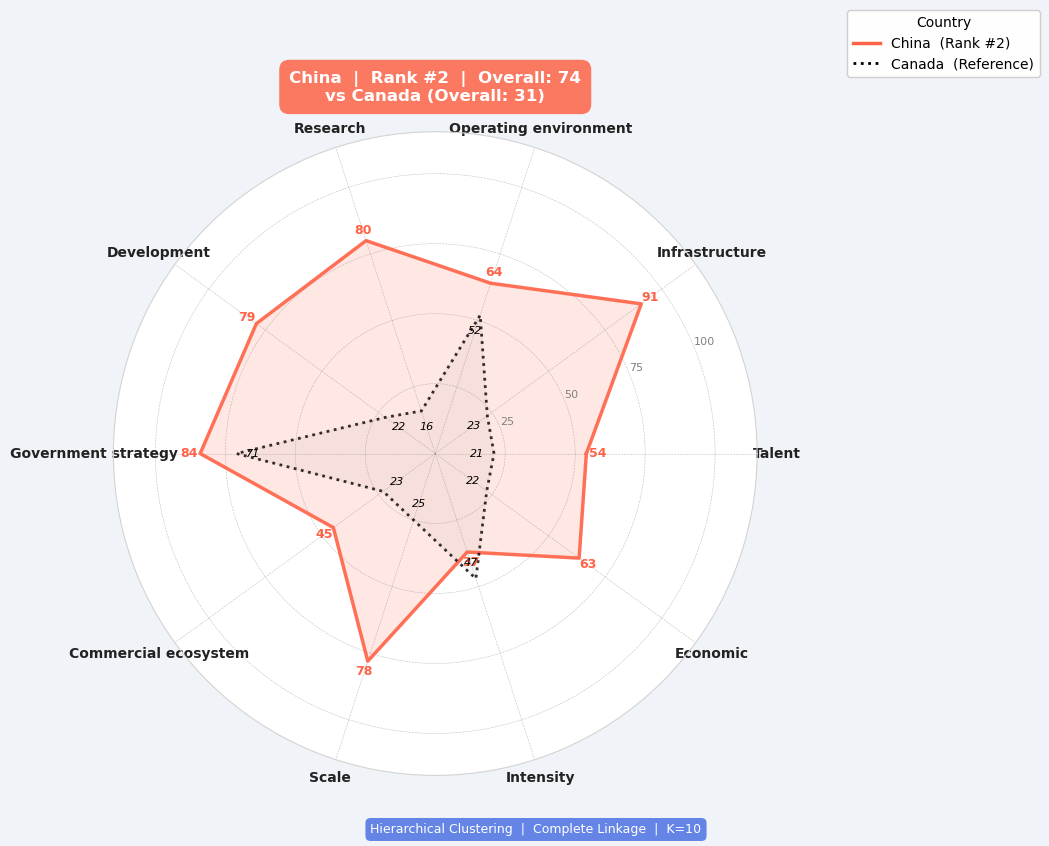

✅ Saved: spider_China_vs_Canada.png


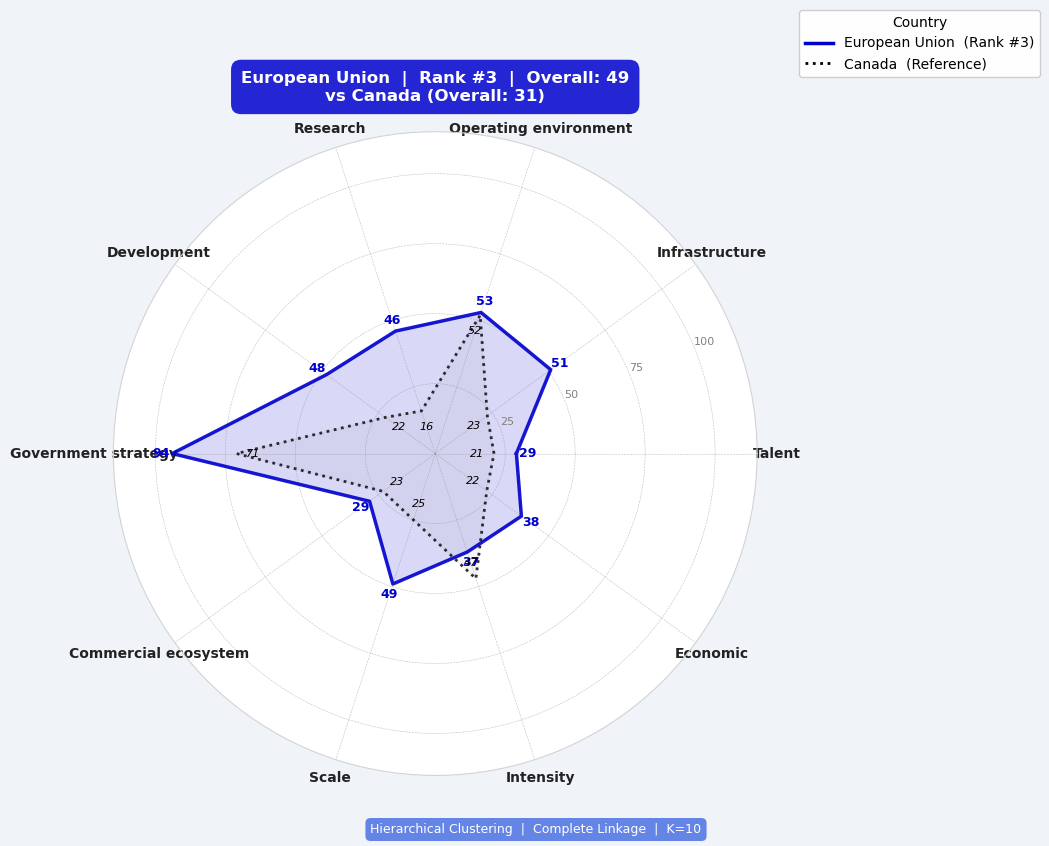

✅ Saved: spider_European_Union_vs_Canada.png


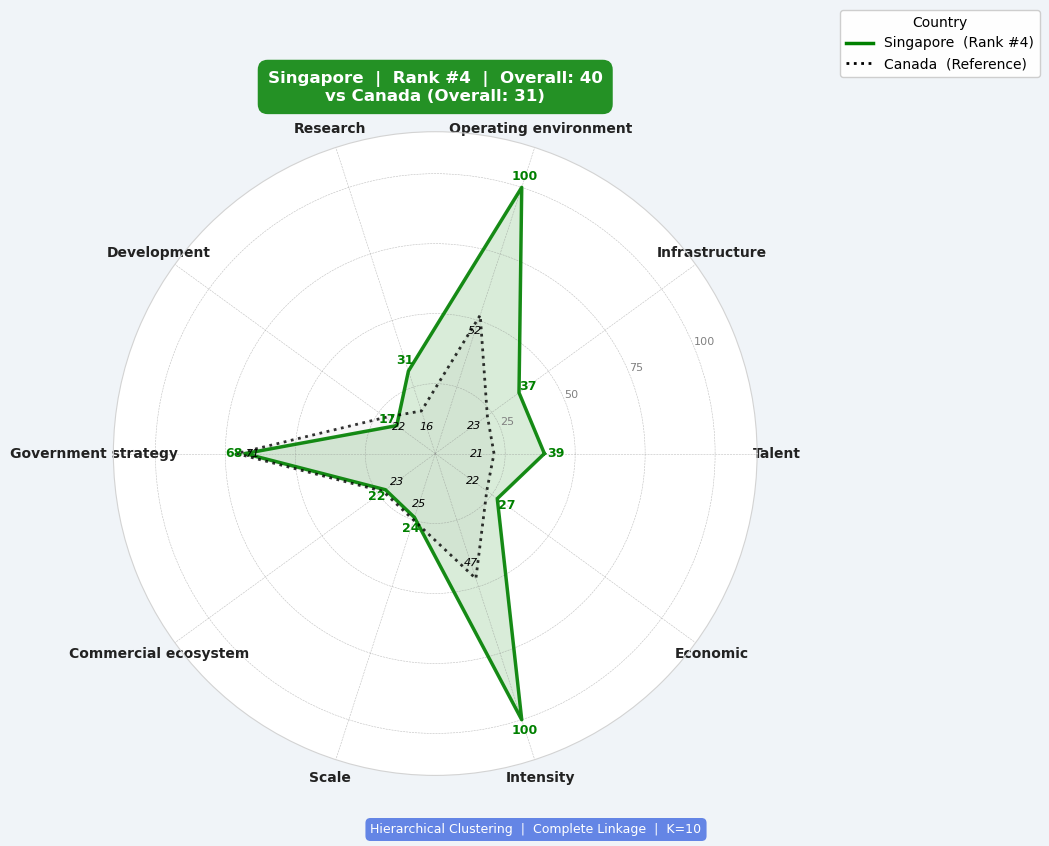

✅ Saved: spider_Singapore_vs_Canada.png


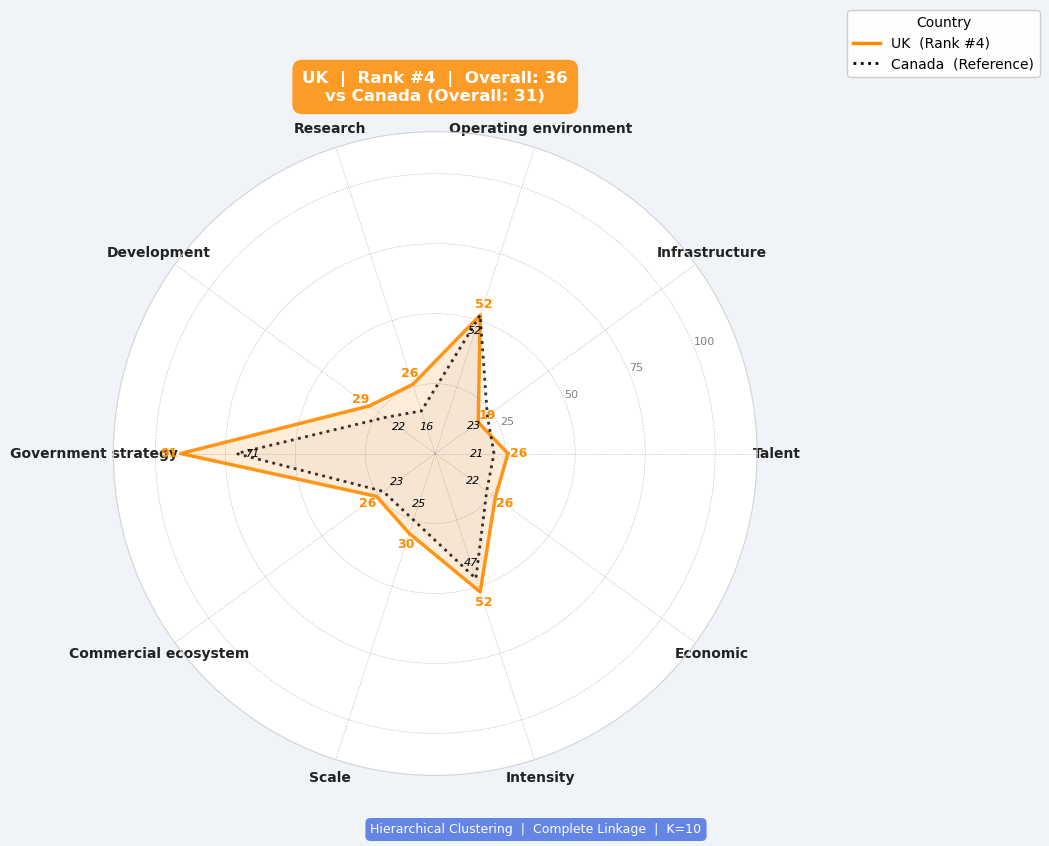

✅ Saved: spider_UK_vs_Canada.png


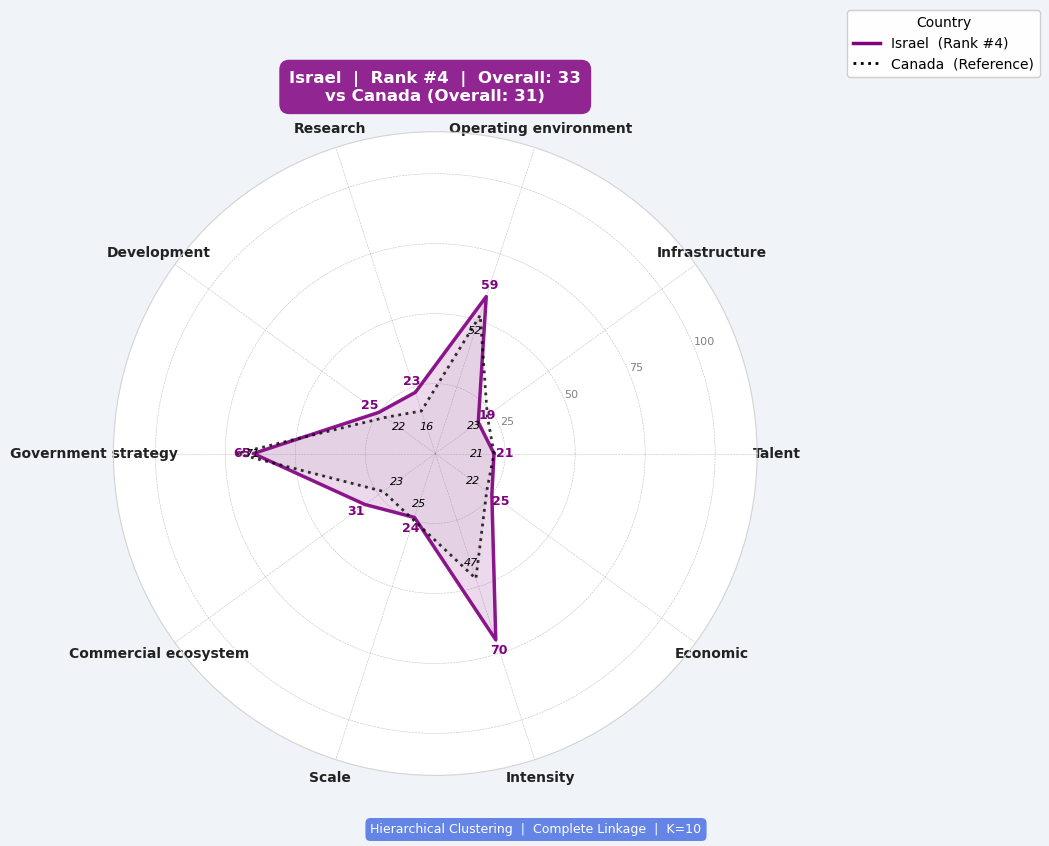

✅ Saved: spider_Israel_vs_Canada.png


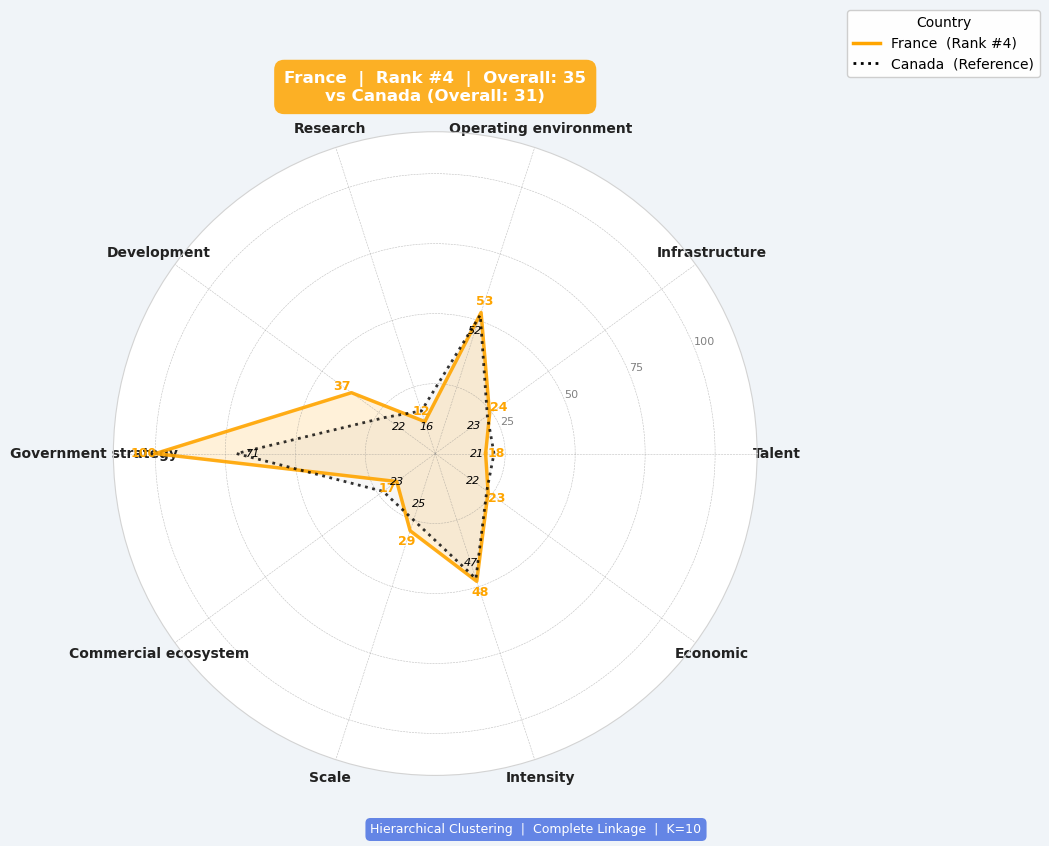

✅ Saved: spider_France_vs_Canada.png

🎉 All individual spider charts saved!


In [ ]:
# ── Countries above Canada ────────────────────────────────────────
above_canada = ['US', 'China', 'European Union', 'Singapore', 'UK', 'Israel','France']

country_colors = {
    'US'             : 'gold',
    'China'          : 'tomato',
    'European Union' : 'mediumblue',
    'Singapore'      : 'green',
    'UK'             : 'darkorange',
    'Israel'         : 'purple',
    'France'         : 'orange'
}

country_rank_label = {
    'US'             : 'Rank #1',
    'China'          : 'Rank #2',
    'European Union' : 'Rank #3',
    'Singapore'      : 'Rank #4',
    'UK'             : 'Rank #4',
    'Israel'         : 'Rank #4',
    'France'         : 'Rank #4',
}

# ── Spider setup ─────────────────────────────────────────────────
all_features = ['Talent', 'Infrastructure', 'Operating environment',
                'Research', 'Development', 'Government strategy',
                'Commercial ecosystem', 'Scale', 'Intensity', 'Economic']

N      = len(all_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# ── Canada reference ──────────────────────────────────────────────
canada      = df[df['Country'] == 'Canada'].iloc[0]
canada_vals = [canada[f] for f in all_features]
canada_vals += canada_vals[:1]

# ── Individual chart per country ──────────────────────────────────
for country in above_canada:
    row   = df[df['Country'] == country].iloc[0]
    color = country_colors[country]
    rank  = country_rank_label[country]

    fig, ax = plt.subplots(figsize=(10, 9), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor('#f0f4f8')
    ax.set_facecolor('#ffffff')

    # ── Country spider ────────────────────────────────────────────
    values  = [row[f] for f in all_features]
    values += values[:1]

    ax.plot(angles, values,
            color=color, linewidth=2.5,
            linestyle='solid', alpha=0.9,
            label=f'{country}  ({rank})')
    ax.fill(angles, values, color=color, alpha=0.15)

    # Score labels
    for angle, value in zip(angles[:-1], values[:-1]):
        ax.text(angle, value + 4, f'{int(value)}',
                ha='center', va='center',
                fontsize=9, color=color, fontweight='bold')

    # ── Canada reference ──────────────────────────────────────────
    ax.plot(angles, canada_vals,
            color='black', linewidth=2,
            linestyle=':', alpha=0.8,
            label='Canada (Reference)')
    ax.fill(angles, canada_vals, color='black', alpha=0.03)

    # Canada score labels
    for angle, value in zip(angles[:-1], canada_vals[:-1]):
        ax.text(angle, value - 6, f'{int(value)}',
                ha='center', va='center',
                fontsize=8, color='black', fontstyle='italic')

    # ── Styling ───────────────────────────────────────────────────
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(all_features, fontsize=10,
                       color='#222222', fontweight='bold')
    ax.set_ylim(0, 115)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(['25', '50', '75', '100'], fontsize=8, color='gray')
    ax.grid(color='gray', linestyle='--', linewidth=0.4, alpha=0.5)
    ax.spines['polar'].set_color('lightgray')

    # ── Legend ────────────────────────────────────────────────────
    legend_handles = [
        plt.Line2D([0], [0], color=color,   linewidth=2.5,
                   linestyle='solid', label=f'{country}  ({rank})'),
        plt.Line2D([0], [0], color='black', linewidth=2,
                   linestyle=':',     label='Canada  (Reference)'),
    ]
    ax.legend(handles=legend_handles,
              loc='upper right',
              bbox_to_anchor=(1.45, 1.2),
              fontsize=10, framealpha=0.95,
              title='Country', title_fontsize=10)

    # ── Title ─────────────────────────────────────────────────────
    overall = int(row['Overall'])
    ax.set_title(
        f'{country}  |  {rank}  |  Overall: {overall}\nvs Canada (Overall: {int(canada["Overall"])})',
        size=12, fontweight='bold', color='white', pad=22,
        bbox=dict(boxstyle='round,pad=0.6',
                  facecolor=color, edgecolor='none', alpha=0.85)
    )

    # ── Bottom badge ──────────────────────────────────────────────
    fig.text(0.5, 0.01,
             f'Hierarchical Clustering  |  Complete Linkage  |  K=10',
             ha='center', fontsize=9, color='white',
             bbox=dict(boxstyle='round,pad=0.4',
                       facecolor='royalblue', edgecolor='none', alpha=0.8))

    plt.tight_layout()
    filename = f'spider_{country.replace(" ", "_")}_vs_Canada.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    plt.close()
    print(f"✅ Saved: {filename}")

print("\n🎉 All individual spider charts saved!")

In [ ]:
import plotly.figure_factory as ff
import numpy as np
from scipy.cluster.hierarchy import linkage

# ── Compute linkage ───────────────────────────────────────────────
linked = linkage(X, method='complete')

# ── Create Plotly dendrogram ──────────────────────────────────────
fig = ff.create_dendrogram(
    X.values,
    orientation='bottom',
    labels=df['Country'].values,
    linkagefun=lambda x: linkage(x, method='complete'),
    color_threshold=0  # no auto coloring — we handle it via slider
)

# ── Styling ───────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='Hierarchical Clustering Dendrogram — Complete Linkage',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    width=max(1200, len(df) * 30),
    height=700,
    paper_bgcolor='#f0f4f8',
    plot_bgcolor='#ffffff',
    font=dict(family='Arial', size=11),
    xaxis=dict(
        tickangle=-45,
        tickfont=dict(size=11, color='#222222'),
        showgrid=False,
        zeroline=False,
    ),
    yaxis=dict(
        title='Distance',
        titlefont=dict(size=13),
        showgrid=True,
        gridcolor='lightgray',
        zeroline=False,
    ),
    margin=dict(l=80, r=40, t=80, b=180),
    shapes=[],      # no static cut line
    annotations=[]  # no static annotation
)

# ── Get y-axis range for slider ───────────────────────────────────
y_max = float(np.max(linked[:, 2])) * 1.05
y_min = 0.0

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Dendrogram — AI Ranking 2025</title>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        * {{ box-sizing: border-box; }}

        body {{
            background-color: #f0f4f8;
            font-family: Arial, sans-serif;
            margin: 0;
            padding: 20px;
        }}
        h2 {{
            text-align: center;
            color: #222222;
            font-size: 22px;
            margin-bottom: 5px;
        }}
        p.subtitle {{
            text-align: center;
            color: #666;
            font-size: 13px;
            margin-bottom: 15px;
        }}

        /* ── Info bar ── */
        .info-bar {{
            display: flex;
            justify-content: center;
            align-items: center;
            gap: 15px;
            margin: 10px 0 15px 0;
            flex-wrap: wrap;
        }}
        .badge {{
            background: royalblue;
            color: white;
            padding: 6px 16px;
            border-radius: 20px;
            font-size: 13px;
            font-weight: bold;
        }}
        .badge.red    {{ background: tomato;   }}
        .badge.green  {{ background: seagreen; }}
        .badge.purple {{ background: #7b2d8b;  }}

        /* ── Reset button ── */
        #reset-btn {{
            background: #222222;
            color: white;
            border: none;
            padding: 8px 20px;
            border-radius: 20px;
            font-size: 13px;
            font-weight: bold;
            cursor: pointer;
            transition: background 0.2s, transform 0.1s;
            display: flex;
            align-items: center;
            gap: 6px;
        }}
        #reset-btn:hover  {{ background: #444; transform: scale(1.04); }}
        #reset-btn:active {{ transform: scale(0.97); }}

        /* ── Main layout: slider on left, plot on right ── */
        .main-layout {{
            display: flex;
            align-items: stretch;
            gap: 0px;
            width: 100%;
        }}

        /* ── Vertical slider panel ── */
        .slider-panel {{
            display: flex;
            flex-direction: column;
            align-items: center;
            justify-content: center;
            background: white;
            border-radius: 10px 0 0 10px;
            box-shadow: 2px 0 8px rgba(0,0,0,0.07);
            padding: 20px 10px;
            min-width: 70px;
            gap: 10px;
        }}
        .slider-label {{
            font-size: 11px;
            color: #555;
            font-weight: bold;
            text-align: center;
            writing-mode: vertical-rl;
            transform: rotate(180deg);
            letter-spacing: 1px;
        }}
        #cut-slider {{
            -webkit-appearance: slider-vertical;
            writing-mode: vertical-lr;
            direction: rtl;
            width: 28px;
            height: 500px;
            cursor: pointer;
            accent-color: tomato;
        }}
        .slider-value-box {{
            background: tomato;
            color: white;
            border-radius: 8px;
            padding: 5px 8px;
            font-size: 12px;
            font-weight: bold;
            text-align: center;
            min-width: 52px;
        }}
        .slider-hint {{
            font-size: 10px;
            color: #aaa;
            text-align: center;
        }}

        /* ── Dendrogram container ── */
        #dendrogram-container {{
            overflow-x: auto;
            overflow-y: hidden;
            flex: 1;
            background: white;
            border-radius: 0 10px 10px 0;
            box-shadow: 0 2px 12px rgba(0,0,0,0.1);
            padding: 10px;
        }}
        #dendrogram {{
            min-width: {max(1200, len(df) * 30)}px;
        }}

        /* ── Cluster count badge ── */
        #cluster-badge {{
            background: tomato;
            transition: background 0.3s;
        }}
    </style>
</head>
<body>

    <h2>Hierarchical Clustering Dendrogram — AI Ranking 2025</h2>
    <p class="subtitle">Complete Linkage &nbsp;|&nbsp; Drag the slider to adjust the cut threshold &nbsp;|&nbsp; Scroll horizontally to see all countries</p>

    <div class="info-bar">
        <span class="badge">Countries: {len(df)}</span>
        <span class="badge red" id="cluster-badge">Clusters: —</span>
        <span class="badge green">Method: Complete Linkage</span>
        <span class="badge purple">Features: Commercial Ecosystem · Economic · Overall</span>
        <button id="reset-btn" onclick="resetView()">
            <span>⟳</span> Reset View
        </button>
    </div>

    <div class="main-layout">

        <!-- ── Vertical slider ── -->
        <div class="slider-panel">
            <span class="slider-label">CUT THRESHOLD</span>
            <input  type="range"
                    id="cut-slider"
                    min="0"
                    max="{y_max:.4f}"
                    step="{y_max / 1000:.4f}"
                    value="{y_max / 2:.4f}"
                    oninput="updateCutLine(this.value)">
            <div class="slider-value-box" id="slider-val">—</div>
            <div class="slider-hint">↑ higher<br>↓ lower</div>
        </div>

        <!-- ── Dendrogram ── -->
        <div id="dendrogram-container">
            <div id="dendrogram"></div>
        </div>

    </div>

    <script>
        // ── Plot ─────────────────────────────────────────────────
        var figData    = {fig.to_json()};
        var plotlyData = figData.data;
        var layout     = figData.layout;

        var plotWidth  = Math.max(1200, {len(df)} * 30);
        layout.width   = plotWidth;
        layout.height  = 700;

        // Add initial cut line shape
        layout.shapes = [{{
            type     : 'line',
            x0       : 0, x1: 1,
            xref     : 'paper',
            y0       : {y_max / 2:.4f},
            y1       : {y_max / 2:.4f},
            line     : {{ color: 'tomato', width: 2.5, dash: 'dash' }}
        }}];

        layout.annotations = [{{
            x         : 0.01,
            xref      : 'paper',
            y         : {y_max / 2:.4f},
            text      : '  ← Cut threshold',
            showarrow : false,
            font      : {{ color: 'tomato', size: 12 }},
            bgcolor   : 'white',
            bordercolor: 'tomato',
            borderwidth: 1
        }}];

        Plotly.newPlot('dendrogram', plotlyData, layout, {{
            responsive     : false,
            displayModeBar : true,
            modeBarButtonsToRemove: ['lasso2d', 'select2d'],
            scrollZoom     : true
        }});

        // ── Linkage distances for cluster counting ────────────────
        var linkageDistances = {list(np.round(linked[:, 2], 6).tolist())};
        var nLeaves          = {len(df)};

        function countClusters(threshold) {{
            // Count merges that happen ABOVE threshold
            var mergesAbove = linkageDistances.filter(d => d > threshold).length;
            return mergesAbove + 1;
        }}

        // ── Update cut line ───────────────────────────────────────
        function updateCutLine(val) {{
            val = parseFloat(val);

            // Update line + annotation
            Plotly.relayout('dendrogram', {{
                'shapes[0].y0'      : val,
                'shapes[0].y1'      : val,
                'annotations[0].y'  : val,
            }});

            // Update slider value display
            document.getElementById('slider-val').innerHTML =
                val.toFixed(1);

            // Update cluster count badge
            var k = countClusters(val);
            var badge = document.getElementById('cluster-badge');
            badge.innerHTML = 'Clusters: ' + k;

            // Color badge by cluster count
            if      (k <= 3)  badge.style.background = 'seagreen';
            else if (k <= 6)  badge.style.background = 'royalblue';
            else if (k <= 10) badge.style.background = 'tomato';
            else              badge.style.background = '#7b2d8b';
        }}

        // ── Init display ──────────────────────────────────────────
        updateCutLine({y_max / 2:.4f});

        // ── Reset view ────────────────────────────────────────────
        function resetView() {{
            // Reset zoom
            Plotly.relayout('dendrogram', {{
                'xaxis.autorange': true,
                'yaxis.autorange': true
            }});

            // Reset slider to midpoint
            var mid = {y_max / 2:.4f};
            document.getElementById('cut-slider').value = mid;
            updateCutLine(mid);

            // Scroll container back
            document.getElementById('dendrogram-container').scrollLeft = 0;

            // Button feedback
            var btn = document.getElementById('reset-btn');
            btn.style.background = 'seagreen';
            btn.innerHTML        = '<span>✓</span> View Reset';
            setTimeout(function() {{
                btn.style.background = '#222222';
                btn.innerHTML        = '<span>⟳</span> Reset View';
            }}, 1200);
        }}
    </script>

</body>
</html>
"""

with open('dendrogram_scrollable.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

print("✅ Saved: dendrogram_scrollable.html")
print("   Open in any browser — drag the vertical slider to adjust cut threshold!")

✅ Saved: dendrogram_scrollable.html
   Open in any browser — drag the vertical slider to adjust cut threshold!


In [ ]:
import plotly.figure_factory as ff
import numpy as np
from scipy.cluster.hierarchy import linkage

# ── Compute linkage ───────────────────────────────────────────────
linked = linkage(X, method='complete')

# ── Tight width calculation ───────────────────────────────────────
n_countries = len(df)
plot_width  = n_countries * 18 + 100

# ── Create Plotly dendrogram ──────────────────────────────────────
fig = ff.create_dendrogram(
    X.values,
    orientation='bottom',
    labels=df['Country'].values,
    linkagefun=lambda x: linkage(x, method='complete'),
    color_threshold=0
)

# ── Styling ───────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='Hierarchical Clustering Dendrogram — Complete Linkage',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    width=plot_width,
    height=700,
    paper_bgcolor='#f0f4f8',
    plot_bgcolor='#ffffff',
    font=dict(family='Arial', size=11),
    xaxis=dict(
        tickangle=-45,
        tickfont=dict(size=11, color='#222222'),
        showgrid=False,
        zeroline=False,
    ),
    yaxis=dict(
        title='Distance',
        titlefont=dict(size=13),
        showgrid=True,
        gridcolor='lightgray',
        zeroline=False,
    ),
    margin=dict(l=80, r=40, t=80, b=180),
    shapes=[],
    annotations=[]
)

# ── Y axis range for slider ───────────────────────────────────────
y_max = float(np.max(linked[:, 2])) * 1.05
y_min = 0.0

# ── HTML ─────────────────────────────────────────────────────────
html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Dendrogram — AI Ranking 2025</title>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        * {{ box-sizing: border-box; }}

        body {{
            background-color: #f0f4f8;
            font-family: Arial, sans-serif;
            margin: 0;
            padding: 20px;
        }}
        h2 {{
            text-align: center;
            color: #222222;
            font-size: 22px;
            margin-bottom: 5px;
        }}
        p.subtitle {{
            text-align: center;
            color: #666;
            font-size: 13px;
            margin-bottom: 15px;
        }}

        /* ── Info bar ── */
        .info-bar {{
            display: flex;
            justify-content: center;
            align-items: center;
            gap: 15px;
            margin: 10px 0 15px 0;
            flex-wrap: wrap;
        }}
        .badge {{
            background: royalblue;
            color: white;
            padding: 6px 16px;
            border-radius: 20px;
            font-size: 13px;
            font-weight: bold;
        }}
        .badge.red    {{ background: tomato;   }}
        .badge.green  {{ background: seagreen; }}
        .badge.purple {{ background: #7b2d8b;  }}

        /* ── Reset button ── */
        #reset-btn {{
            background: #222222;
            color: white;
            border: none;
            padding: 8px 20px;
            border-radius: 20px;
            font-size: 13px;
            font-weight: bold;
            cursor: pointer;
            transition: background 0.2s, transform 0.1s;
            display: flex;
            align-items: center;
            gap: 6px;
        }}
        #reset-btn:hover  {{ background: #444; transform: scale(1.04); }}
        #reset-btn:active {{ transform: scale(0.97); }}

        /* ── Main layout ── */
        .main-layout {{
            display: flex;
            align-items: stretch;
            gap: 0px;
            width: 100%;
        }}

        /* ── Vertical slider panel ── */
        .slider-panel {{
            display: flex;
            flex-direction: column;
            align-items: center;
            justify-content: center;
            background: white;
            border-radius: 10px 0 0 10px;
            box-shadow: 2px 0 8px rgba(0,0,0,0.07);
            padding: 20px 10px;
            min-width: 70px;
            gap: 10px;
        }}
        .slider-label {{
            font-size: 11px;
            color: #555;
            font-weight: bold;
            text-align: center;
            writing-mode: vertical-rl;
            transform: rotate(180deg);
            letter-spacing: 1px;
        }}
        #cut-slider {{
            -webkit-appearance: slider-vertical;
            writing-mode: vertical-lr;
            direction: rtl;
            width: 28px;
            height: 500px;
            cursor: pointer;
            accent-color: tomato;
        }}
        .slider-value-box {{
            background: tomato;
            color: white;
            border-radius: 8px;
            padding: 5px 8px;
            font-size: 12px;
            font-weight: bold;
            text-align: center;
            min-width: 52px;
        }}
        .slider-hint {{
            font-size: 10px;
            color: #aaa;
            text-align: center;
        }}

        /* ── Dendrogram container ── */
        #dendrogram-container {{
            overflow-x: auto;
            overflow-y: hidden;
            flex: 1;
            background: white;
            border-radius: 0 10px 10px 0;
            box-shadow: 0 2px 12px rgba(0,0,0,0.1);
            padding: 10px;
        }}
        #dendrogram {{
            width: {plot_width}px;
        }}

        /* ── Cluster badge ── */
        #cluster-badge {{
            background: tomato;
            transition: background 0.3s;
        }}
    </style>
</head>
<body>

    <h2>Hierarchical Clustering Dendrogram — AI Ranking 2025</h2>
    <p class="subtitle">
        Complete Linkage &nbsp;|&nbsp;
        Drag the slider to adjust the cut threshold &nbsp;|&nbsp;
        Scroll horizontally to see all countries
    </p>

    <div class="info-bar">
        <span class="badge">Countries: {n_countries}</span>
        <span class="badge red" id="cluster-badge">Clusters: —</span>
        <span class="badge green">Method: Complete Linkage</span>
        <span class="badge purple">
            Features: Commercial Ecosystem · Economic · Overall
        </span>
        <button id="reset-btn" onclick="resetView()">
            <span>⟳</span> Reset View
        </button>
    </div>

    <div class="main-layout">

        <!-- ── Vertical slider ── -->
        <div class="slider-panel">
            <span class="slider-label">CUT THRESHOLD</span>
            <input  type="range"
                    id="cut-slider"
                    min="0"
                    max="{y_max:.4f}"
                    step="{y_max / 1000:.4f}"
                    value="{y_max / 2:.4f}"
                    oninput="updateCutLine(this.value)">
            <div class="slider-value-box" id="slider-val">—</div>
            <div class="slider-hint">↑ higher<br>↓ lower</div>
        </div>

        <!-- ── Dendrogram ── -->
        <div id="dendrogram-container">
            <div id="dendrogram"></div>
        </div>

    </div>

    <script>
        // ── Plot ─────────────────────────────────────────────────
        var figData    = {fig.to_json()};
        var plotlyData = figData.data;
        var layout     = figData.layout;

        layout.width   = {plot_width};
        layout.height  = 700;

        // Initial cut line
        layout.shapes = [{{
            type  : 'line',
            x0    : 0,   x1  : 1,
            xref  : 'paper',
            y0    : {y_max / 2:.4f},
            y1    : {y_max / 2:.4f},
            line  : {{ color: 'tomato', width: 2.5, dash: 'dash' }}
        }}];

        layout.annotations = [{{
            x          : 0.01,
            xref       : 'paper',
            y          : {y_max / 2:.4f},
            text       : '  ← Cut threshold',
            showarrow  : false,
            font       : {{ color: 'tomato', size: 12 }},
            bgcolor    : 'white',
            bordercolor: 'tomato',
            borderwidth: 1
        }}];

        Plotly.newPlot('dendrogram', plotlyData, layout, {{
            responsive            : false,
            displayModeBar        : true,
            modeBarButtonsToRemove: ['lasso2d', 'select2d'],
            scrollZoom            : true
        }});

        // ── Linkage distances for cluster count ───────────────────
        var linkageDistances = {list(np.round(linked[:, 2], 6).tolist())};

        function countClusters(threshold) {{
            var mergesAbove = linkageDistances.filter(d => d > threshold).length;
            return mergesAbove + 1;
        }}

        // ── Update cut line ───────────────────────────────────────
        function updateCutLine(val) {{
            val = parseFloat(val);

            Plotly.relayout('dendrogram', {{
                'shapes[0].y0'    : val,
                'shapes[0].y1'    : val,
                'annotations[0].y': val,
            }});

            // Slider value display
            document.getElementById('slider-val').innerHTML = val.toFixed(1);

            // Cluster count + badge color
            var k     = countClusters(val);
            var badge = document.getElementById('cluster-badge');
            badge.innerHTML = 'Clusters: ' + k;

            if      (k <= 3)  badge.style.background = 'seagreen';
            else if (k <= 6)  badge.style.background = 'royalblue';
            else if (k <= 10) badge.style.background = 'tomato';
            else              badge.style.background = '#7b2d8b';
        }}

        // ── Init ─────────────────────────────────────────────────
        updateCutLine({y_max / 2:.4f});

        // ── Reset view ────────────────────────────────────────────
        function resetView() {{
            Plotly.relayout('dendrogram', {{
                'xaxis.autorange': true,
                'yaxis.autorange': true
            }});

            var mid = {y_max / 2:.4f};
            document.getElementById('cut-slider').value = mid;
            updateCutLine(mid);

            document.getElementById('dendrogram-container').scrollLeft = 0;

            var btn          = document.getElementById('reset-btn');
            btn.style.background = 'seagreen';
            btn.innerHTML        = '<span>✓</span> View Reset';
            setTimeout(function() {{
                btn.style.background = '#222222';
                btn.innerHTML        = '<span>⟳</span> Reset View';
            }}, 1200);
        }}
    </script>

</body>
</html>
"""

with open('dendrogram_scrollable.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"✅ Saved: dendrogram_scrollable.html")
print(f"   Plot width: {plot_width}px  ({n_countries} countries × 18px + 100px padding)")
print(f"   Open in any browser — drag slider to adjust cut threshold!")

✅ Saved: dendrogram_scrollable.html
   Plot width: 1792px  (94 countries × 18px + 100px padding)
   Open in any browser — drag slider to adjust cut threshold!
